In [8]:
import pathlib
from os import path, getcwd, chdir

import numpy as np
from tqdm import tqdm

chdir(r'C:\Users\IanFu\Desktop\~1_CURRENT\efsprapy\01-analysis\sensitivity_sprinkler_type')


def read_data(parent_dir: pathlib.Path) -> (list, list):
    folders = [item for item in parent_dir.iterdir() if item.is_dir()]
    folders.sort()
    processed_data = dict()
    for folder in tqdm(folders):
        case_name = folder.name
        fp_output = folder / f'{folder.name}_out.csv'
        try:
            assert path.exists(fp_output), f'file does not exist {fp_output}'
        except AssertionError:
            continue
        mcs_output = np.genfromtxt(fp_output, delimiter=",", skip_header=1)

        N = np.shape(mcs_output)[0]

        # find all iterations that ignition occurred
        t_ig_ftp = mcs_output[:, 2]
        P_ig = sum(np.logical_and(t_ig_ftp > 0, t_ig_ftp < np.inf)) / N

        processed_data[case_name] = P_ig
    return processed_data


data = read_data(pathlib.Path(getcwd(), 'sprinkler_type'))
# data = {
#     'residential': data['residential'],
#     'office': data['office'],
#     'retail': data['retail'],
#     'reference': data['reference'],
# }

100%|██████████| 4/4 [00:00<00:00, 592.81it/s]


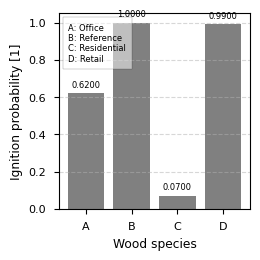

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-paper')

fig, ax2 = plt.subplots(figsize=(2.7, 2.7), dpi=100)

bars2 = ax2.bar(data.keys(), data.values(), color='grey')
# ax2.text(0.98, 0.98, f"Eurocode timber @ 300 ℃\nIgnition probability {data['safir_40mm']['safir_40mm']}", ha='right', va='top', color='red', fontsize=7, transform=ax2.transAxes)
legend_text = '\n'.join(f'{"ABCDEFG"[i]}: {name.replace("_", " ").title()}' for i, name in enumerate(data.keys()))
ax2.text(0.05, 0.95, legend_text, ha='left', va='top', color='k', fontsize=6, transform=ax2.transAxes,
         bbox=dict(facecolor='white', alpha=0.5))
ax2.set_ylabel('Ignition probability [1]')
ax2.set_xlabel('Wood species')
ax2.set_xticks(range(len(data)))
ax2.set_xticklabels(['ABCDEFGH'[i] for i in range(len(data))], rotation=0)
ax2.bar_label(bars2, fmt='%.4f', padding=3, fontsize=6)
ax2.grid(True, linestyle='--', alpha=0.5, axis='y')

# ax2.set_ylim(0, 0.1)

fig.tight_layout()

In [10]:
data

{'office': np.float64(0.62),
 'reference': np.float64(1.0),
 'residential': np.float64(0.07),
 'retail': np.float64(0.99)}